# 01 — PlantVillage Classification Data Preparation and Bias Audit — FINAL

## Why this corrected version exists

The first classification-preparation notebook successfully created the four intended views, but its class-distribution audit exposed an important problem:

```text
Corn_(maize)___healthy
Train = 9
Validation = 2
Test = 0
Total = 11
```

That happened because the notebook reused the **segmentation-final 52,969-sample manifest**.  
That manifest was appropriate for segmentation because it deliberately removed segmented-image sources with unreliable explicit backgrounds. However, that segmentation-specific filtering was highly disproportionate for `Corn_(maize)___healthy`.

A 38-class classifier cannot be evaluated rigorously when one class has **zero test samples**.

## Final correction

Classification therefore uses the earlier **paired + initial-QC dataset**:

- Total: **54,304**
- Train: **43,443**
- Validation: **5,430**
- Test: **5,431**
- Classes: **38**

The split is still the original fixed, class-stratified 80:10:10 split.

To obtain a consistent leaf mask for **every classification sample**, this notebook uses the already trained final **U-Net + ResNet34 segmentation model** as a mask generator.

This is methodologically useful because:

```text
Completed segmentation model
          ↓
leaf mask for every classification image
          ↓
leaf-only / background-only / counterfactual views
          ↓
bias-aware classification experiments
```

The classification study therefore remains connected to the segmentation study without inheriting the segmentation-specific source-filtering imbalance.

## Requirements before Run All

Use a **T4 GPU** for the one-time mask-generation stage.

The Drive should contain:

```text
MyDrive/PlantVillage_Segmentation/
├── plantvillage_split_80_10_10_seed42_qc.csv
└── experiments/
    └── UNet/
        └── checkpoints/
            └── best_unet.pth
```

If `best_unet.pth` is not in that location, the notebook also checks:

```text
MyDrive/PlantVillage_Classification/source_models/best_unet.pth
```

Mask generation is saved in **restartable chunks**. If Colab disconnects, simply Run All again; already completed mask chunks are skipped.


# STEP 1 — Install Libraries

In [1]:
!pip -q install kagglehub segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


# STEP 2 — Imports, GPU, and Reproducibility

In [2]:
import os
import gc
import json
import hashlib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import kagglehub
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Enable a T4 GPU for the one-time U-Net mask generation."
    )

print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


# STEP 3 — Download PlantVillage and Detect Dataset Root

In [3]:
download_path = Path(
    kagglehub.dataset_download(
        "abdallahalidev/plantvillage-dataset"
    )
)

def find_dataset_root(base):

    required = {
        "color",
        "grayscale",
        "segmented"
    }

    candidates = [base] + [
        p for p in base.rglob("*")
        if p.is_dir()
    ]

    for path in candidates:

        try:
            names = {
                p.name
                for p in path.iterdir()
                if p.is_dir()
            }

            if required.issubset(
                names
            ):
                return path

        except PermissionError:
            pass

    return None


dataset_root = find_dataset_root(
    download_path
)

assert dataset_root is not None

print(
    "Dataset root:",
    dataset_root
)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset root: /kaggle/input/plantvillage-dataset/plantvillage dataset


# STEP 4 — Mount Drive and Define Project Paths

In [4]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

SEGMENTATION_PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "PlantVillage_Segmentation"
)

CLASSIFICATION_PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "PlantVillage_Classification"
)

MASK_CHUNK_DIR = (
    CLASSIFICATION_PROJECT_DIR /
    "mask_chunks"
)

SOURCE_MODEL_DIR = (
    CLASSIFICATION_PROJECT_DIR /
    "source_models"
)

ARTIFACT_DIR = (
    CLASSIFICATION_PROJECT_DIR /
    "artifacts"
)

VISUAL_DIR = (
    CLASSIFICATION_PROJECT_DIR /
    "visuals"
)

for folder in [
    CLASSIFICATION_PROJECT_DIR,
    MASK_CHUNK_DIR,
    SOURCE_MODEL_DIR,
    ARTIFACT_DIR,
    VISUAL_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print(
    "Classification project:",
    CLASSIFICATION_PROJECT_DIR
)


Mounted at /content/drive
Classification project: /content/drive/MyDrive/PlantVillage_Classification


# STEP 5 — Load the Correct Classification Source Split

In [5]:
SOURCE_SPLIT = (
    SEGMENTATION_PROJECT_DIR /
    "plantvillage_split_80_10_10_seed42_qc.csv"
)

assert SOURCE_SPLIT.exists(), (
    "Missing plantvillage_split_80_10_10_seed42_qc.csv. "
    "Copy the preprocessing artifacts from the completed segmentation project."
)

source_df = pd.read_csv(
    SOURCE_SPLIT
)

print(
    "Total:",
    len(source_df)
)

print()

print(
    source_df[
        "split"
    ].value_counts()
)

print()

print(
    "Classes:",
    source_df[
        "class"
    ].nunique()
)

assert len(source_df) == 54304
assert (source_df["split"] == "train").sum() == 43443
assert (source_df["split"] == "val").sum() == 5430
assert (source_df["split"] == "test").sum() == 5431
assert source_df["class"].nunique() == 38

print(
    "\n✅ Correct classification source split verified."
)


Total: 54304

split
train    43443
test      5431
val       5430
Name: count, dtype: int64

Classes: 38

✅ Correct classification source split verified.


# STEP 6 — Audit Per-Class Split Counts

In [6]:
class_split = (
    source_df
    .groupby(
        [
            "class",
            "split"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

class_split[
    "total"
] = class_split.sum(
    axis=1
)

display(
    class_split
)

zero_test_classes = (
    class_split[
        class_split.get(
            "test",
            0
        ) == 0
    ]
)

print(
    "Classes with zero test samples:",
    len(
        zero_test_classes
    )
)

print(
    "Minimum total samples/class:",
    int(
        class_split[
            "total"
        ].min()
    )
)

assert len(
    zero_test_classes
) == 0

print(
    "✅ Every class has test representation."
)


split,test,train,val,total
class,,,,
Apple___Apple_scab,63,504,63,630
Apple___Black_rot,62,497,62,621
Apple___Cedar_apple_rust,27,220,28,275
Apple___healthy,165,1316,164,1645
Blueberry___healthy,150,1202,150,1502
Cherry_(including_sour)___Powdery_mildew,105,842,105,1052
Cherry_(including_sour)___healthy,85,683,86,854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,51,410,52,513
Corn_(maize)___Common_rust_,120,953,119,1192


Classes with zero test samples: 0
Minimum total samples/class: 152
✅ Every class has test representation.


# STEP 7 — Build Stable Classification Manifest

In [7]:
class_names = sorted(
    source_df[
        "class"
    ].unique()
)

class_to_id = {
    name: i
    for i, name
    in enumerate(
        class_names
    )
}

id_to_class = {
    i: name
    for name, i
    in class_to_id.items()
}

classification_df = (
    source_df.copy()
    .reset_index(
        drop=True
    )
)

classification_df[
    "class_id"
] = (
    classification_df[
        "class"
    ]
    .map(
        class_to_id
    )
    .astype(int)
)

classification_df[
    "sample_id"
] = (
    classification_df[
        "color_rel"
    ]
    .apply(
        lambda x:
            hashlib.sha1(
                x.encode(
                    "utf-8"
                )
            )
            .hexdigest()[:16]
    )
)

assert classification_df[
    "sample_id"
].duplicated().sum() == 0

print(
    "Samples:",
    len(
        classification_df
    )
)

print(
    "Classes:",
    len(
        class_names
    )
)


Samples: 54304
Classes: 38


# STEP 8 — Locate and Load the Final U-Net Mask Generator

In [8]:
UNET_CANDIDATES = [
    (
        SEGMENTATION_PROJECT_DIR /
        "experiments" /
        "UNet" /
        "checkpoints" /
        "best_unet.pth"
    ),
    (
        SOURCE_MODEL_DIR /
        "best_unet.pth"
    )
]

UNET_CHECKPOINT = None

for candidate in UNET_CANDIDATES:

    if candidate.exists():

        UNET_CHECKPOINT = candidate
        break


assert UNET_CHECKPOINT is not None, (
    "best_unet.pth was not found. Copy the completed U-Net best checkpoint "
    "to PlantVillage_Classification/source_models/best_unet.pth "
    "or preserve the original segmentation experiment path."
)

print(
    "U-Net checkpoint:",
    UNET_CHECKPOINT
)


unet_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
).to(
    DEVICE
)


checkpoint = torch.load(
    UNET_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)


unet_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


unet_model.eval()


print(
    "Checkpoint epoch:",
    checkpoint.get(
        "epoch"
    )
)

print(
    "Best validation Dice:",
    checkpoint.get(
        "best_val_dice"
    )
)

print(
    "✅ Final U-Net restored."
)


U-Net checkpoint: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/checkpoints/best_unet.pth
Checkpoint epoch: 26
Best validation Dice: 0.9911337333271303
✅ Final U-Net restored.


# STEP 9 — U-Net Inference Dataset

In [9]:
UNET_IMAGE_SIZE = 256

unet_transform = transforms.Compose([
    transforms.Resize(
        (
            UNET_IMAGE_SIZE,
            UNET_IMAGE_SIZE
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


class ClassificationMaskInferenceDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        dataset_root
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.dataset_root = Path(
            dataset_root
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]

        image = Image.open(
            self.dataset_root /
            row[
                "color_rel"
            ]
        ).convert(
            "RGB"
        )

        image_tensor = (
            unet_transform(
                image
            )
        )

        return {
            "image":
                image_tensor,

            "sample_id":
                row[
                    "sample_id"
                ]
        }


# STEP 10 — Generate Restartable Packed-Mask Chunks

In [10]:
# Every mask is packed from 256x256 bits to 8192 bytes.
# Chunk files are persistent in Drive and make preprocessing resumable.

CHUNK_SIZE = 2048
MASK_THRESHOLD = 0.5

num_chunks = (
    len(
        classification_df
    )
    +
    CHUNK_SIZE
    -
    1
) // CHUNK_SIZE


print(
    "Samples:",
    len(
        classification_df
    )
)

print(
    "Chunk size:",
    CHUNK_SIZE
)

print(
    "Chunks:",
    num_chunks
)


for chunk_id in range(
    num_chunks
):

    start = (
        chunk_id
        *
        CHUNK_SIZE
    )

    end = min(
        start
        +
        CHUNK_SIZE,
        len(
            classification_df
        )
    )

    chunk_path = (
        MASK_CHUNK_DIR /
        f"mask_chunk_{chunk_id:03d}.npz"
    )


    if chunk_path.exists():

        print(
            f"✅ Chunk {chunk_id:03d} already exists — skipping."
        )

        continue


    chunk_df = (
        classification_df
        .iloc[
            start:end
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    chunk_dataset = (
        ClassificationMaskInferenceDataset(
            chunk_df,
            dataset_root
        )
    )


    chunk_loader = DataLoader(
        chunk_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )


    packed_masks = []
    sample_ids = []
    foreground_fractions = []


    with torch.no_grad():

        for batch in tqdm(
            chunk_loader,
            desc=f"Mask chunk {chunk_id:03d}"
        ):

            images = (
                batch[
                    "image"
                ]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )


            with torch.amp.autocast(
                device_type="cuda"
            ):

                logits = (
                    unet_model(
                        images
                    )
                )


            masks = (
                torch.sigmoid(
                    logits
                )
                >=
                MASK_THRESHOLD
            )


            masks_np = (
                masks[
                    :,
                    0
                ]
                .cpu()
                .numpy()
                .astype(
                    np.uint8
                )
            )


            for mask in masks_np:

                foreground_fractions.append(
                    float(
                        mask.mean()
                    )
                )


                packed = np.packbits(
                    mask.reshape(
                        -1
                    )
                )


                packed_masks.append(
                    packed
                )


            sample_ids.extend(
                list(
                    batch[
                        "sample_id"
                    ]
                )
            )


    packed_masks = np.stack(
        packed_masks
    ).astype(
        np.uint8
    )


    foreground_fractions = np.asarray(
        foreground_fractions,
        dtype=np.float32
    )


    np.savez_compressed(
        chunk_path,
        sample_ids=np.asarray(
            sample_ids,
            dtype="<U16"
        ),
        packed_masks=packed_masks,
        foreground_fraction=
            foreground_fractions
    )


    print(
        f"💾 Saved chunk {chunk_id:03d}:",
        chunk_path
    )


print(
    "\n✅ Mask chunk generation stage finished."
)


Samples: 54304
Chunk size: 2048
Chunks: 27


Mask chunk 000:   0%|          | 0/32 [00:00<?, ?it/s]

💾 Saved chunk 000: /content/drive/MyDrive/PlantVillage_Classification/mask_chunks/mask_chunk_000.npz


Mask chunk 001:   0%|          | 0/32 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d288642c540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.13/threading.py", line 1088, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d288642c540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    Exception ignored in: if w.is_alive():<function _MultiProcessingD

...

Mask chunk 025:   0%|          | 0/32 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d288642c540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d288642c540>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d288642c540>Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/tor

💾 Saved chunk 025: /content/drive/MyDrive/PlantVillage_Classification/mask_chunks/mask_chunk_025.npz


Mask chunk 026:   0%|          | 0/17 [00:00<?, ?it/s]

💾 Saved chunk 026: /content/drive/MyDrive/PlantVillage_Classification/mask_chunks/mask_chunk_026.npz

✅ Mask chunk generation stage finished.


# STEP 11 — Consolidate All Mask Chunks

In [11]:
MASK_ARCHIVE = (
    CLASSIFICATION_PROJECT_DIR /
    "classification_unet_masks_packed.npz"
)


if MASK_ARCHIVE.exists():

    print(
        "✅ Consolidated mask archive already exists:",
        MASK_ARCHIVE
    )

else:

    all_ids = []
    all_masks = []
    all_fg = []


    for chunk_id in tqdm(
        range(
            num_chunks
        ),
        desc="Consolidating chunks"
    ):

        chunk_path = (
            MASK_CHUNK_DIR /
            f"mask_chunk_{chunk_id:03d}.npz"
        )

        assert chunk_path.exists(), (
            f"Missing mask chunk: {chunk_path}"
        )


        with np.load(
            chunk_path
        ) as chunk:

            all_ids.append(
                chunk[
                    "sample_ids"
                ]
            )

            all_masks.append(
                chunk[
                    "packed_masks"
                ]
            )

            all_fg.append(
                chunk[
                    "foreground_fraction"
                ]
            )


    all_ids = np.concatenate(
        all_ids
    )

    all_masks = np.concatenate(
        all_masks,
        axis=0
    )

    all_fg = np.concatenate(
        all_fg
    )


    assert len(
        all_ids
    ) == len(
        classification_df
    )

    assert all_masks.shape[
        0
    ] == len(
        classification_df
    )


    np.savez_compressed(
        MASK_ARCHIVE,
        sample_ids=
            all_ids,

        packed_masks=
            all_masks,

        foreground_fraction=
            all_fg
    )


    del (
        all_ids,
        all_masks,
        all_fg
    )

    gc.collect()


    print(
        "💾 Saved:",
        MASK_ARCHIVE
    )


Consolidating chunks:   0%|          | 0/27 [00:00<?, ?it/s]

💾 Saved: /content/drive/MyDrive/PlantVillage_Classification/classification_unet_masks_packed.npz


# STEP 12 — Mask Quality Audit

In [12]:
with np.load(
    MASK_ARCHIVE
) as mask_data:

    mask_ids = mask_data[
        "sample_ids"
    ].astype(
        str
    )

    foreground_fraction = (
        mask_data[
            "foreground_fraction"
        ]
    )


print(
    "Masks:",
    len(
        mask_ids
    )
)

print(
    "Minimum foreground:",
    foreground_fraction.min()
)

print(
    "Median foreground:",
    np.median(
        foreground_fraction
    )
)

print(
    "Maximum foreground:",
    foreground_fraction.max()
)


invalid_mask = (
    (
        foreground_fraction
        <
        0.001
    )
    |
    (
        foreground_fraction
        >
        0.999
    )
)


invalid_count = int(
    invalid_mask.sum()
)


print(
    "Potential invalid masks:",
    invalid_count
)


MASK_QC_CSV = (
    ARTIFACT_DIR /
    "classification_unet_mask_qc.csv"
)


mask_qc_df = pd.DataFrame({
    "sample_id":
        mask_ids,

    "foreground_fraction":
        foreground_fraction,

    "potential_invalid":
        invalid_mask
})


mask_qc_df.to_csv(
    MASK_QC_CSV,
    index=False
)


if invalid_count > 0:

    print(
        "\n⚠️ Stop and inspect the flagged masks before model training."
    )

else:

    print(
        "\n✅ No effectively empty/full predicted masks."
    )


Masks: 54304
Minimum foreground: 0.024368286
Median foreground: 0.468338
Maximum foreground: 1.0
Potential invalid masks: 346

⚠️ Stop and inspect the flagged masks before model training.


# STEP 13 — Add Fixed Counterfactual Donor Mapping

In [13]:
rng = np.random.default_rng(
    SEED
)

classification_df[
    "counterfactual_partner_id"
] = None


for split_name in [
    "train",
    "val",
    "test"
]:

    split_indices = (
        classification_df.index[
            classification_df[
                "split"
            ]
            ==
            split_name
        ]
        .to_numpy()
    )

    split_classes = (
        classification_df.loc[
            split_indices,
            "class_id"
        ]
        .to_numpy()
    )


    by_class = {
        class_id:
            split_indices[
                split_classes
                ==
                class_id
            ]

        for class_id in range(
            38
        )
    }


    for idx in tqdm(
        split_indices,
        desc=f"Partner mapping: {split_name}"
    ):

        source_class = int(
            classification_df.at[
                idx,
                "class_id"
            ]
        )


        candidate_classes = [
            class_id
            for class_id in range(38)
            if (
                class_id != source_class
                and len(by_class[class_id]) > 0
            )
        ]


        donor_class = int(
            rng.choice(
                candidate_classes
            )
        )


        donor_idx = int(
            rng.choice(
                by_class[
                    donor_class
                ]
            )
        )


        classification_df.at[
            idx,
            "counterfactual_partner_id"
        ] = (
            classification_df.at[
                donor_idx,
                "sample_id"
            ]
        )


assert classification_df[
    "counterfactual_partner_id"
].isna().sum() == 0

print(
    "✅ Fixed donor mapping created."
)


Partner mapping: train:   0%|          | 0/43443 [00:00<?, ?it/s]

Partner mapping: val:   0%|          | 0/5430 [00:00<?, ?it/s]

Partner mapping: test:   0%|          | 0/5431 [00:00<?, ?it/s]

✅ Fixed donor mapping created.


# STEP 14 — Load Packed Masks for Visual Audit

In [14]:
with np.load(
    MASK_ARCHIVE
) as data:

    packed_masks = data[
        "packed_masks"
    ]

    packed_ids = data[
        "sample_ids"
    ].astype(
        str
    )


mask_index = {
    sample_id:
        index
    for index, sample_id
    in enumerate(
        packed_ids
    )
}


def get_mask(
    sample_id
):

    packed = packed_masks[
        mask_index[
            str(
                sample_id
            )
        ]
    ]


    mask = np.unpackbits(
        packed
    )[
        :
        256 * 256
    ].reshape(
        256,
        256
    )


    return mask.astype(
        np.uint8
    )


print(
    "Masks loaded for audit:",
    len(
        mask_index
    )
)


Masks loaded for audit: 54304


# STEP 15 — Define Bias-Audit Views

In [15]:
NEUTRAL_RGB = np.array(
    [
        124,
        116,
        104
    ],
    dtype=np.uint8
)


def make_leaf_only(
    image,
    mask
):

    if mask.shape != image.shape[:2]:

        mask = cv2.resize(
            mask,
            (
                image.shape[
                    1
                ],
                image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_NEAREST
        )


    output = np.empty_like(
        image
    )

    output[:] = (
        NEUTRAL_RGB
    )

    output[
        mask == 1
    ] = image[
        mask == 1
    ]


    return output


def make_background_only(
    image,
    mask
):

    if mask.shape != image.shape[:2]:

        mask = cv2.resize(
            mask,
            (
                image.shape[
                    1
                ],
                image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_NEAREST
        )


    output = image.copy()

    output[
        mask == 1
    ] = NEUTRAL_RGB


    return output


def make_clean_donor_background(
    donor_image,
    donor_mask
):

    if donor_mask.shape != donor_image.shape[:2]:

        donor_mask = cv2.resize(
            donor_mask,
            (
                donor_image.shape[
                    1
                ],
                donor_image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_NEAREST
        )


    output = donor_image.copy()


    background_pixels = output[
        donor_mask == 0
    ]


    fill_rgb = (
        np.median(
            background_pixels,
            axis=0
        )
        .astype(
            np.uint8
        )
        if
        len(
            background_pixels
        )
        >
        0
        else
        NEUTRAL_RGB
    )


    output[
        donor_mask == 1
    ] = fill_rgb


    output = cv2.GaussianBlur(
        output,
        (
            15,
            15
        ),
        0
    )


    return output


def make_counterfactual(
    target_image,
    target_mask,
    donor_background
):

    if target_mask.shape != target_image.shape[:2]:

        target_mask = cv2.resize(
            target_mask,
            (
                target_image.shape[
                    1
                ],
                target_image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_NEAREST
        )


    if donor_background.shape[:2] != target_image.shape[:2]:

        donor_background = cv2.resize(
            donor_background,
            (
                target_image.shape[
                    1
                ],
                target_image.shape[
                    0
                ]
            ),
            interpolation=
                cv2.INTER_LINEAR
        )


    output = donor_background.copy()

    output[
        target_mask == 1
    ] = target_image[
        target_mask == 1
    ]


    return output


# STEP 16 — Visual Bias-Audit Examples

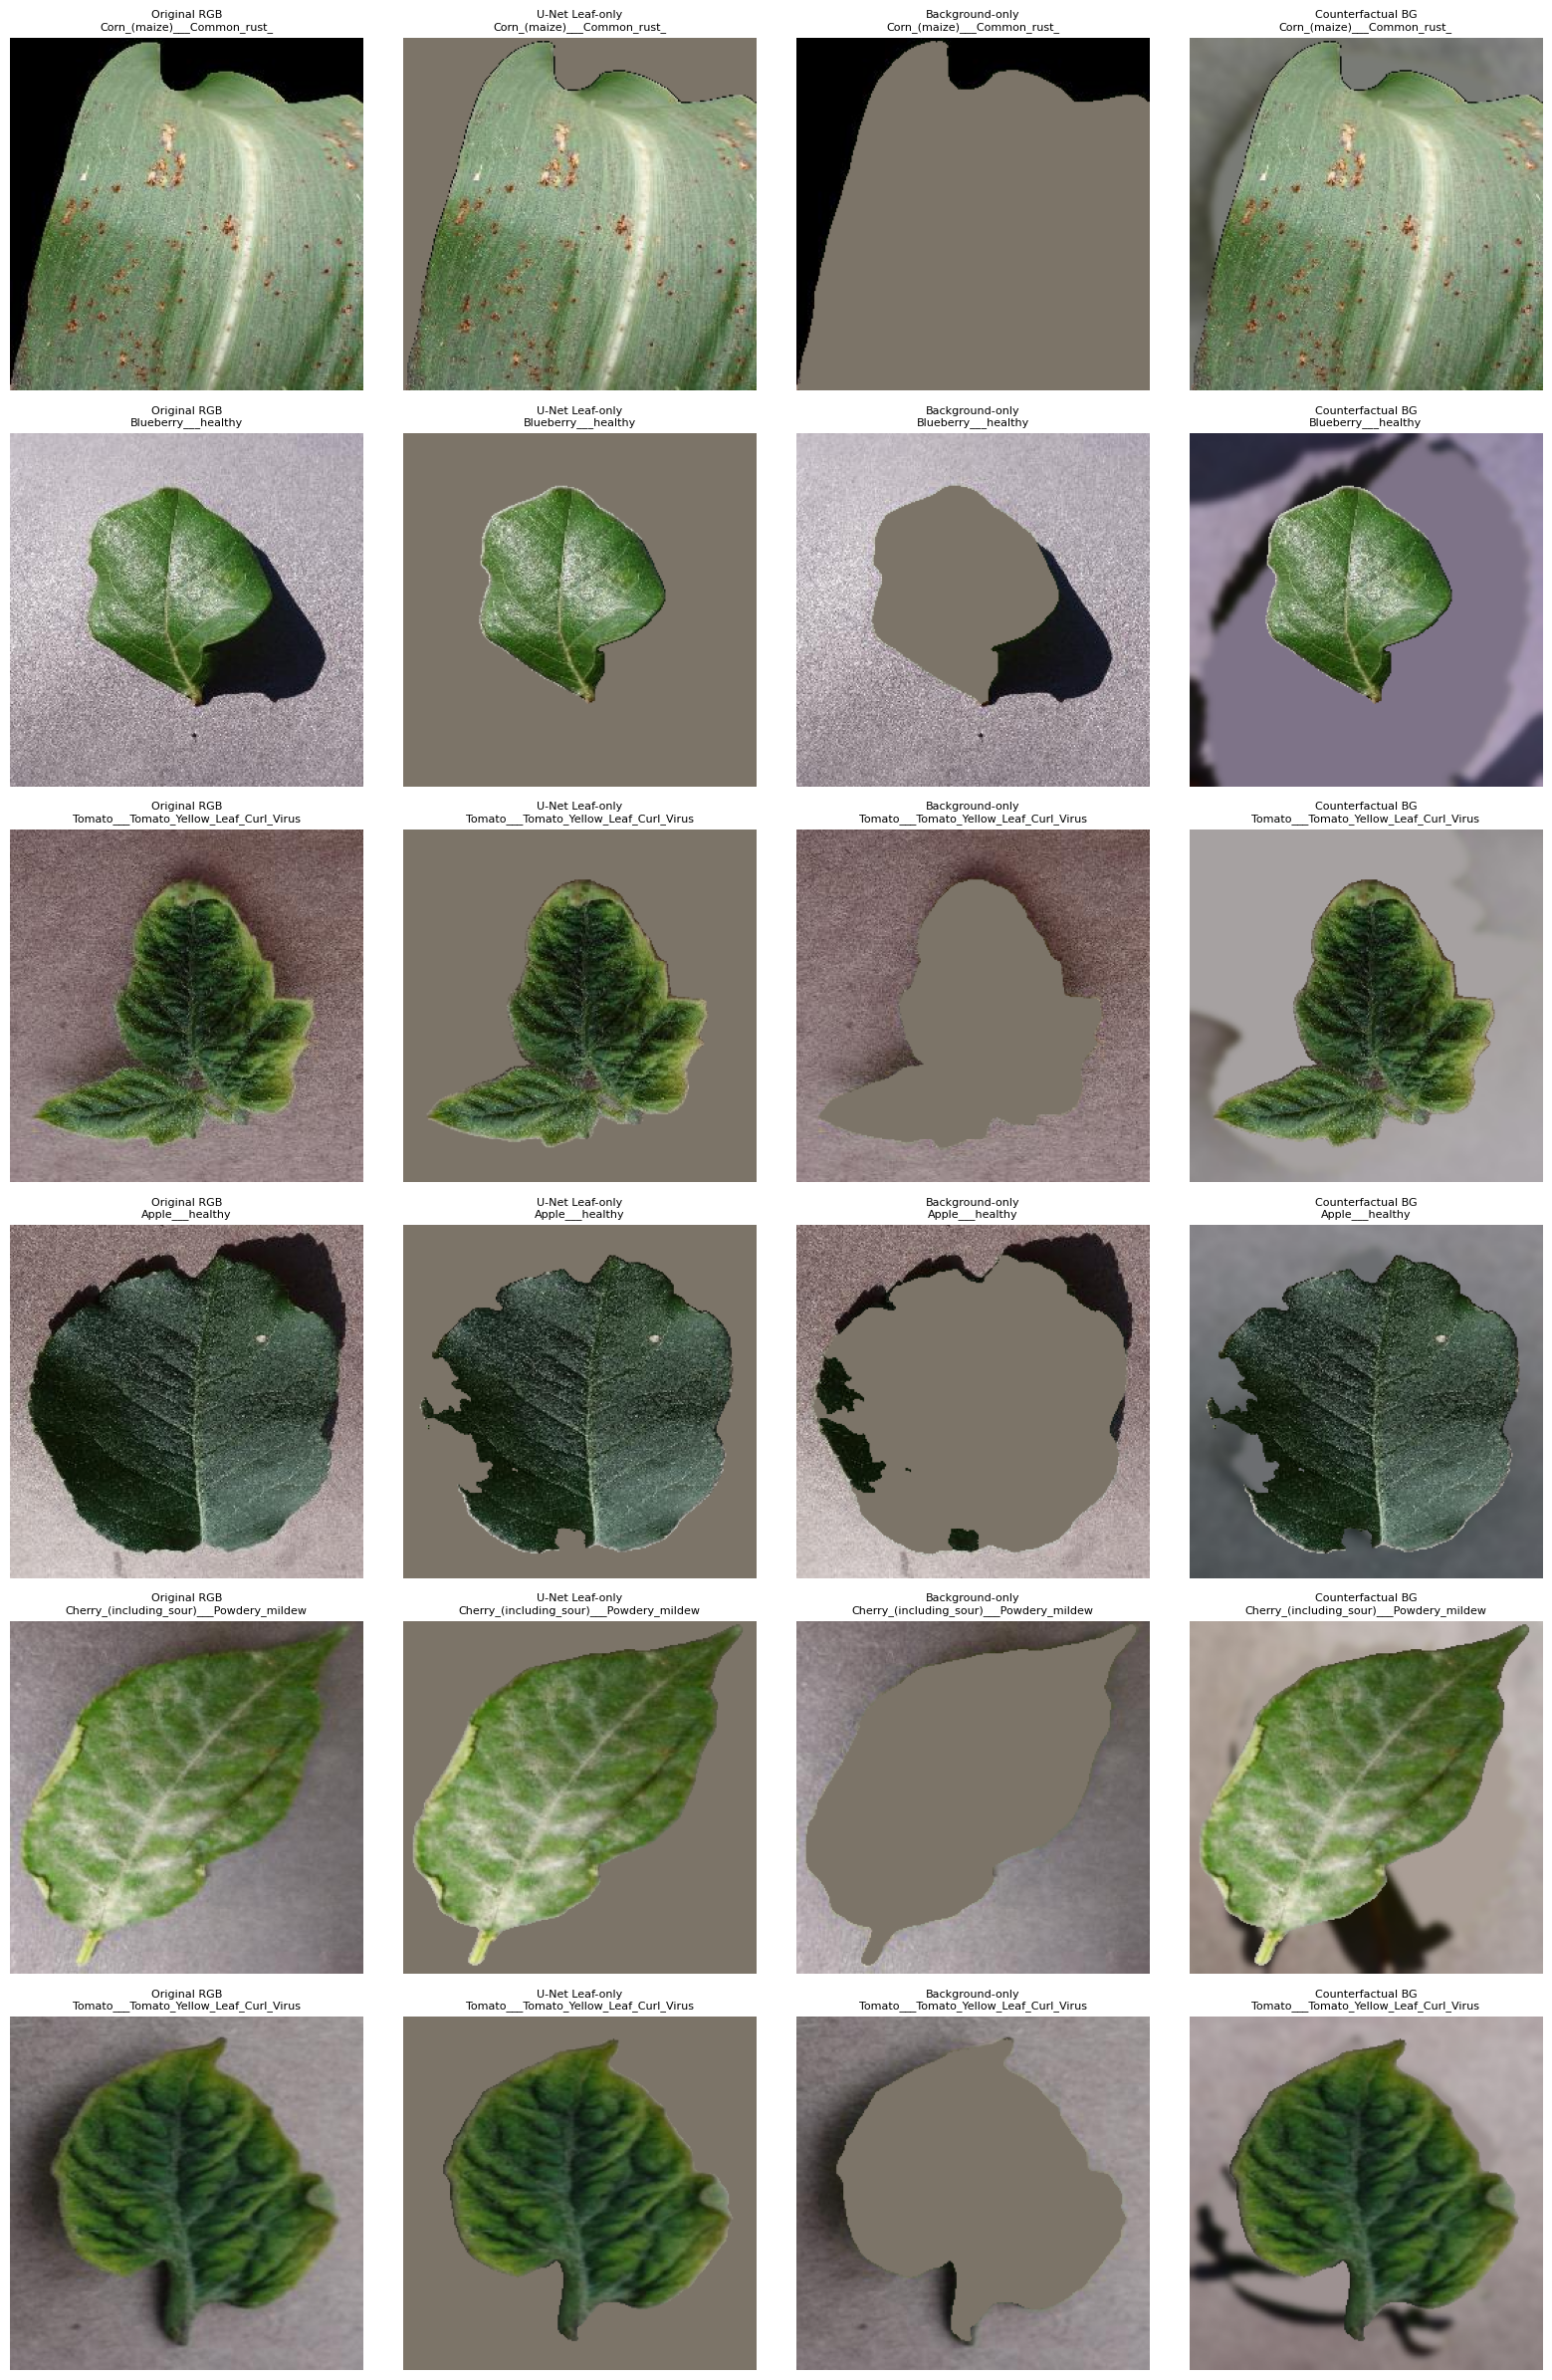

Saved: /content/drive/MyDrive/PlantVillage_Classification/visuals/classification_bias_audit_views_v2.png


In [16]:
sample_to_row = (
    classification_df
    .set_index(
        "sample_id"
    )
)


preview_rows = (
    classification_df
    .sample(
        n=6,
        random_state=SEED
    )
    .reset_index(
        drop=True
    )
)


fig, axes = plt.subplots(
    len(
        preview_rows
    ),
    4,
    figsize=(
        16,
        4 * len(
            preview_rows
        )
    )
)


for row_idx, row in preview_rows.iterrows():

    target_image = np.array(
        Image.open(
            dataset_root /
            row[
                "color_rel"
            ]
        ).convert(
            "RGB"
        )
    )


    target_mask = get_mask(
        row[
            "sample_id"
        ]
    )


    donor_row = sample_to_row.loc[
        row[
            "counterfactual_partner_id"
        ]
    ]


    donor_image = np.array(
        Image.open(
            dataset_root /
            donor_row[
                "color_rel"
            ]
        ).convert(
            "RGB"
        )
    )


    donor_mask = get_mask(
        donor_row.name
    )


    donor_background = (
        make_clean_donor_background(
            donor_image,
            donor_mask
        )
    )


    views = [
        target_image,

        make_leaf_only(
            target_image,
            target_mask
        ),

        make_background_only(
            target_image,
            target_mask
        ),

        make_counterfactual(
            target_image,
            target_mask,
            donor_background
        )
    ]


    titles = [
        "Original RGB",
        "U-Net Leaf-only",
        "Background-only",
        "Counterfactual BG"
    ]


    for column, (
        view,
        title
    ) in enumerate(
        zip(
            views,
            titles
        )
    ):

        axes[
            row_idx,
            column
        ].imshow(
            view
        )


        axes[
            row_idx,
            column
        ].set_title(
            f"{title}\n"
            f"{row['class']}",
            fontsize=8
        )


        axes[
            row_idx,
            column
        ].axis(
            "off"
        )


plt.tight_layout()


BIAS_AUDIT_FIG = (
    VISUAL_DIR /
    "classification_bias_audit_views_v2.png"
)


plt.savefig(
    BIAS_AUDIT_FIG,
    dpi=250,
    bbox_inches="tight"
)


plt.show()


print(
    "Saved:",
    BIAS_AUDIT_FIG
)


# STEP 17 — Save Final Classification V2 Manifest and Config

In [17]:
FINAL_MANIFEST = (
    CLASSIFICATION_PROJECT_DIR /
    "final_classification_manifest_v2.csv"
)


CLASS_MAP_PATH = (
    CLASSIFICATION_PROJECT_DIR /
    "classification_class_map_v2.json"
)


CONFIG_PATH = (
    CLASSIFICATION_PROJECT_DIR /
    "classification_preprocessing_config_v2.json"
)


CLASS_DISTRIBUTION_CSV = (
    ARTIFACT_DIR /
    "class_distribution_by_split_v2.csv"
)


classification_df.to_csv(
    FINAL_MANIFEST,
    index=False
)


with open(
    CLASS_MAP_PATH,
    "w"
) as f:

    json.dump(
        {
            "class_to_id":
                class_to_id,

            "id_to_class":
                {
                    str(k): v
                    for k, v
                    in id_to_class.items()
                }
        },
        f,
        indent=4
    )


class_split.reset_index().to_csv(
    CLASS_DISTRIBUTION_CSV,
    index=False
)


config = {
    "task":
        "38-class PlantVillage disease classification",

    "source":
        "paired PlantVillage dataset after one unusable-source exclusion",

    "mask_generator":
        "completed U-Net ResNet34 segmentation model",

    "mask_prediction_threshold":
        MASK_THRESHOLD,

    "total_samples":
        54304,

    "train_samples":
        43443,

    "validation_samples":
        5430,

    "test_samples":
        5431,

    "classes":
        38,

    "split":
        "original fixed stratified 80:10:10 split, seed 42",

    "counterfactual_partner_rule":
        "same split, different class, seed 42",

    "planned_models": [
        "standard RGB EfficientNet-B0 baseline",
        "leaf-only EfficientNet-B0 teacher",
        "mask-guided counterfactual consistency distillation student"
    ],

    "primary_model_selection_metric":
        "validation macro F1",

    "evaluation_metrics": [
        "accuracy",
        "balanced accuracy",
        "macro precision",
        "macro recall",
        "macro F1",
        "weighted F1"
    ],

    "robustness_views": [
        "original RGB",
        "leaf-only",
        "background-only",
        "counterfactual background"
    ]
}


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


print(
    "Saved:",
    FINAL_MANIFEST
)

print(
    "Saved:",
    MASK_ARCHIVE
)

print(
    "Saved:",
    CONFIG_PATH
)


Saved: /content/drive/MyDrive/PlantVillage_Classification/final_classification_manifest_v2.csv
Saved: /content/drive/MyDrive/PlantVillage_Classification/classification_unet_masks_packed.npz
Saved: /content/drive/MyDrive/PlantVillage_Classification/classification_preprocessing_config_v2.json


# STEP 18 — Final Verification

In [18]:
required = [
    FINAL_MANIFEST,
    MASK_ARCHIVE,
    CLASS_MAP_PATH,
    CONFIG_PATH,
    CLASS_DISTRIBUTION_CSV,
    MASK_QC_CSV,
    BIAS_AUDIT_FIG
]


for path in required:

    exists = Path(
        path
    ).exists()

    print(
        "✅" if exists else "❌",
        path
    )

    assert exists


print()

print(
    classification_df[
        "split"
    ].value_counts()
)

print(
    "Classes:",
    classification_df[
        "class"
    ].nunique()
)

print(
    "Classes with zero test samples:",
    len(
        zero_test_classes
    )
)


if invalid_count == 0:

    print(
        "\n✅ CLASSIFICATION PREPROCESSING V2 IS READY FOR MODEL TRAINING."
    )

else:

    print(
        "\n⚠️ Inspect potential invalid U-Net masks before training."
    )


✅ /content/drive/MyDrive/PlantVillage_Classification/final_classification_manifest_v2.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_unet_masks_packed.npz
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_class_map_v2.json
✅ /content/drive/MyDrive/PlantVillage_Classification/classification_preprocessing_config_v2.json
✅ /content/drive/MyDrive/PlantVillage_Classification/artifacts/class_distribution_by_split_v2.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/artifacts/classification_unet_mask_qc.csv
✅ /content/drive/MyDrive/PlantVillage_Classification/visuals/classification_bias_audit_views_v2.png

split
train    43443
test      5431
val       5430
Name: count, dtype: int64
Classes: 38
Classes with zero test samples: 0

⚠️ Inspect potential invalid U-Net masks before training.
